In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [5]:
#read dataset
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv.zip")

In [6]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(253680, 22)


In [7]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0      

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [9]:
print("\nTarget Distribution:")
print(df["Diabetes_012"].value_counts())


Target Distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [10]:
#duplicates
df = df.drop_duplicates().sample(20000, random_state=42)

In [11]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']


In [12]:
#rtrain & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [13]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [14]:
#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# 5.XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

In [16]:
#training model by using weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
# 7. expectation
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

In [18]:
# 8.evaluation
print("\n" + "="*30)
print("Evaluation Results of the Developed XGBoost Model")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC AUC Score (OVR): {roc_auc_score(y_test, xgb_proba, multi_class='ovr'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))



Evaluation Results of the Developed XGBoost Model
Accuracy Score: 0.6705
ROC AUC Score (OVR): 0.7259

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.69      0.79      3315
         1.0       0.03      0.11      0.04        81
         2.0       0.33      0.65      0.44       604

    accuracy                           0.67      4000
   macro avg       0.43      0.48      0.42      4000
weighted avg       0.82      0.67      0.72      4000



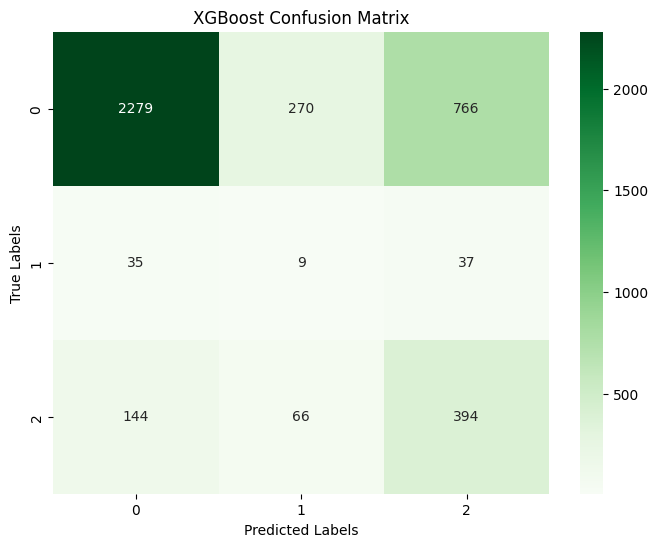

In [19]:
# 9.(Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

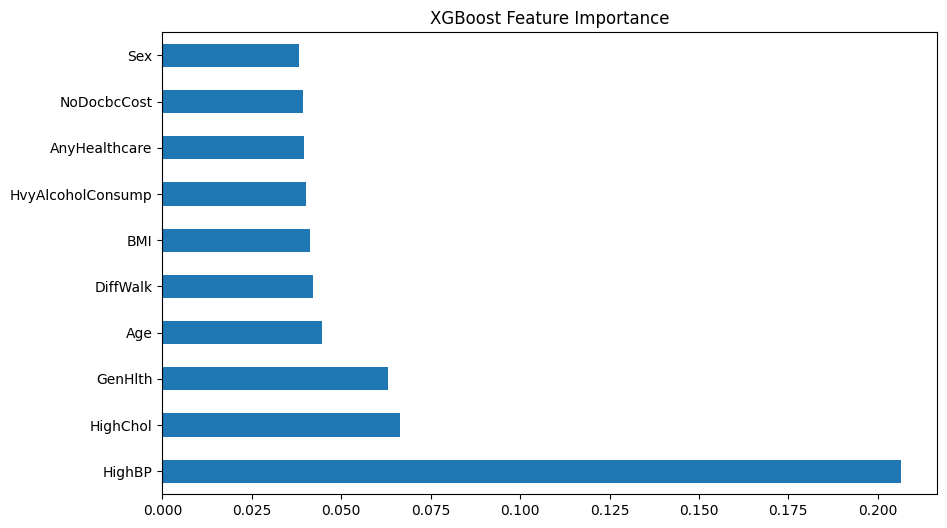

In [20]:
# Feature Importance (For XGBoost)
plt.figure(figsize=(10,6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh') # Show top 10 features
plt.title("XGBoost Feature Importance")
plt.show()